# AutoMode — Gemma-2-9B on RTX PRO 6000 WS (96 GB)

This notebook is a **direct port** of the Gemma-2-2B full-run experiment to Gemma-2-9B,
re-calibrated for the NVIDIA RTX PRO 6000 Workstation GPU (96 GB GDDR7).

### What changed vs the 2B run
| Setting | 2B (RTX 5090 / 33 GB) | 9B (RTX PRO 6000 WS / 96 GB) | Why |
|---|---|---|---|
| `model_checkpoint` | `gemma-2-2b` | `gemma-2-9b` | 9B model |
| `batch_train` | 1 | 4 | 4× VRAM headroom |
| `batch_eval` | 2 | 8 | — |
| `grad_accum` | 16 | 8 | effective batch = 32 (same) |
| `learning_rate` | 5e-5 | 2e-5 | larger models need smaller LR |
| `gen_max_tokens` | 100 | 256 | 9B writes longer CoT chains |
| dtype | `float16` | `bfloat16` | Gemma-2's native training dtype |
| target_modules (ext.) | — | q/k/v/o + gate/up/down | FFN-coverage research direction |
| `topk_deep_block` range | layers 13–19 of 26 | layers 22–35 of 42 | proportional depth |

### Experiment blocks
1. **Controls** — full_ft, LoRA (q+v), AutoMode (q+v) — 3 seeds → direct 2B/9B comparison
2. **AutoMode sweep** — (u,t) ∈ {(6,10),(6,25),(10,25)} — 3 seeds
3. **LoRA rank ablation** — r ∈ {32, 64} — 3 seeds
4. **Full attention coverage** — q/k/v/o — 3 seeds
5. **All-7 coverage** — q/k/v/o + gate/up/down — 2 seeds (expensive)
6. **Static baselines** — topk_full, topk_deep_block — 3 seeds

In [1]:
# ── Cell 1: Install / upgrade dependencies ───────────────────────────────────
#
# transformers ≥ 4.45.0  is required for Gemma-2 sliding-window attention.
# accelerate  ≥ 0.34.0   is required for the bfloat16 device-map path.
# peft        ≥ 0.12.0   is required for the LoraLayer.reset_lora_parameters API.
# bitsandbytes provides AdamW8bit which halves optimizer-state memory vs AdamW.

!pip install -U transformers datasets peft bitsandbytes huggingface_hub \
               pandas tqdm sentencepiece accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 177.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 92.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 240.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 58.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 67.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 100.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 165.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 173.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 183.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.5/801.5 kB 159.7 MB/s  0:00:00
  Attempting uninstall: huggingface_hub90m╺━━━━━━━━━━━━━━ 14/22 [aiohttp]
    Found existing installation: huggingface_hub 1.7.1━━━━━━━━━━━━ 15/22 [huggingface_hub]
    Uninstalling huggingface_hub-1.7.1:m

In [2]:
# ── Cell 2: Imports & hardware sanity check ───────────────────────────────────
#
# We detect VRAM and warn early if the card is too small, so you don't waste
# GPU time only to OOM halfway through the first experiment.

import os, re, gc, json, time, math, hashlib, random, socket
from copy import deepcopy
from dataclasses import dataclass
from collections import defaultdict, Counter
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from datasets import load_dataset, load_from_disk
from datasets.utils.logging import disable_progress_bar
disable_progress_bar()

from transformers import AutoTokenizer, AutoModelForCausalLM, get_scheduler
from bitsandbytes.optim import AdamW8bit
from peft import LoraConfig, get_peft_model, TaskType
from peft.tuners.lora import LoraLayer
from torch.utils.data import DataLoader
from huggingface_hub import login

# Suppress tokenizer fork warnings that clutter the output
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ── Hardware check ──────────────────────────────────────────────────────────
# We pin everything to cuda:0.  If you have multiple GPUs and want to use a
# different one, change DEVICE here — nothing else needs to change.
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

print("Hostname :", socket.gethostname())
print("Device   :", DEVICE)

if torch.cuda.is_available():
    props          = torch.cuda.get_device_properties(0)
    total_vram_gb  = props.total_memory / 1e9
    free_vram_gb   = (props.total_memory - torch.cuda.memory_allocated(0)) / 1e9
    print(f"GPU      : {props.name}")
    print(f"VRAM     : {total_vram_gb:.2f} GB total  /  {free_vram_gb:.2f} GB free")

    # Gemma-2-9B in bfloat16 ≈ 18.5 GB.  We need at least ~50 GB for full_ft
    # (weights + gradients + AdamW8bit states + gradient-checkpointing buffer).
    if total_vram_gb < 50:
        print()
        print("⚠️  WARNING: < 50 GB VRAM detected. Recommended adjustments:")
        print("   batch_train  → 1")
        print("   batch_eval   → 2")
        print("   grad_accum   → 16")
        print("   Skip full_ft experiments or add load_in_4bit=True to get_model().")
else:
    print("⚠️  No CUDA device found — running on CPU (not practical for 9B).")

Hostname : 843d73e409e3
Device   : cuda:0
GPU      : NVIDIA RTX PRO 6000 Blackwell Workstation Edition
VRAM     : 101.97 GB total  /  101.97 GB free


In [18]:
# ── Cell 3: Global config + Experiment Grid ───────────────────────────────────
#
# ALL hyperparameters live here so you can review them in one place before
# launching a 12-hour run.

# ── User settings ────────────────────────────────────────────────────────────
HF_TOKEN        = os.environ.get("HF_TOKEN", "hf_REDACTED")   # or paste directly
SAVE_PATH       = "/workspace/GSM8K_9B_Results"     # all output files go here
os.makedirs(SAVE_PATH, exist_ok=True)

RESULTS_CSV     = f"{SAVE_PATH}/experiments_log.csv"
# Separate cache from the 2B run — the tokenizer may differ slightly
DATA_CACHE_PATH = f"{SAVE_PATH}/gsm8k_tokenized_9b.arrow"

SEEDS           = [8, 25, 42]   # 3 seeds → mean ± std for every config
RUN_FULL_GRID   = True          # set False to run only QUICK_GRID (3 experiments)
FULL_TEST_SIZE  = 1319          # entire GSM8K test set
QUICK_TEST_SIZE = 400           # smoke-test subset

# ── Base config ──────────────────────────────────────────────────────────────
# This dict is mutated per-experiment in run_experiment().  The values below
# are the defaults; any key in an experiment config dict overrides them.
GSM8K_CONFIG = {

    # ── Model ──
    # google/gemma-2-9b is the base (pre-trained, not instruction-tuned) model.
    # Using the base model keeps the setup identical to what we did with 2B.
    "model_checkpoint": "google/gemma-2-9b",
    "seed"            : 42,

    # GSM8K problems + step-by-step answers rarely exceed 700 tokens;
    # 2048 gives comfortable headroom without wasting memory on padding.
    # Gemma-2-9B supports up to 8192 tokens if you need longer contexts.
    "max_input_length": 2048,

    # ── Training ──
    # With 96 GB VRAM:
    #   full_ft  memory: ~18.5 GB weights + ~18.5 GB grads + ~18.5 GB AdamW8bit
    #            ≈ 55 GB before activations.  gradient_checkpointing trades
    #            recompute for activation memory, making batch=4 feasible.
    #   LoRA     memory: ~18.5 GB frozen weights + tiny adapter params ≈ 20 GB.
    #            batch=4 trivially fits with 70+ GB to spare.
    "batch_train": 4,   # ← was 1 for 2B on 33 GB; 4× more throughput

    # At eval time there are no gradients, so memory = weights + KV-cache.
    # batch_eval=8, k=5 → 40 concurrent generation sequences.
    # KV-cache estimate: 40 seqs × 42 layers × 8 KV-heads × 2304 max-len
    #                    × 256 head-dim × 2 bytes ≈ 15 GB.  Fine on 96 GB.
    "batch_eval": 8,    # ← was 2 for 2B

    # Slightly lower than the 5e-5 used for 2B.  Empirically, larger models
    # are more sensitive to learning rate — 2e-5 avoids instability in the
    # full_ft and AutoMode runs while still converging in 2 epochs.
    "learning_rate": 2e-5,
    "epochs"        : 2,
    "weight_decay"  : 0.01,
    "warmup_ratio"  : 0.03,

    # effective batch = batch_train × grad_accum = 4 × 8 = 32.
    # The 2B run had effective batch = 1 × 16 = 16; we double it here.
    # Larger effective batches give smoother gradient estimates, which
    # matters especially for the dynamic layer-switching signal.
    "grad_accum": 8,

    # ── Strategy defaults (overridden per-experiment) ──
    "strategy"         : "dynamic_grad_norm",
    "dynamic_updates"  : 10,   # switching decisions per epoch
    "dynamic_threshold": 10,   # t-th percentile; layers above → Full-FT mode

    # ── LoRA defaults ──
    # r=16 / alpha=32 matches the best-performing config from the 2B paper.
    # Extended target_modules are added in specific grid entries below.
    "lora_r"        : 16,
    "lora_alpha"    : 32,
    "lora_dropout"  : 0.1,
    "target_modules": ["q_proj", "v_proj"],

    # ── Dtype ──
    # Gemma-2 was pre-trained in bfloat16.  Unlike float16, bfloat16 has the
    # same exponent range as float32, which prevents gradient underflow in
    # the FFT layers without needing a loss scaler.
    # fp16=False disables the old float16 path; use_bf16=True activates bfloat16.
    "fp16"   : False,
    "use_bf16": True,

    # ── Generation / eval ──
    # 256 tokens vs 100 for 2B: 9B generates richer chain-of-thought and we
    # don't want to truncate the reasoning before the #### answer marker.
    "sampling_k"    : 5,
    "gen_max_tokens": 256,
}

model_name = GSM8K_CONFIG["model_checkpoint"]

# ── Experiment grid ───────────────────────────────────────────────────────────
FULL_GRID = []

# ── Block 1: Paper-faithful controls (q+v only, same as 2B) ──────────────────
# Running full_ft / LoRA / AutoMode with the same target_modules as the 2B
# paper lets us make a direct 2B→9B comparison.  The key question: does
# AutoMode's advantage over both baselines grow or shrink at 9B scale?
for seed in SEEDS:
    FULL_GRID += [
        {
            "strategy" : "full_ft",
            "sampling_k": 5, "epochs": 2, "seed": seed,
        },
        {
            "strategy" : "lora",
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
            "target_modules": ["q_proj", "v_proj"],
        },
        {
            "strategy" : "dynamic_grad_norm",
            "dynamic_updates": 10, "dynamic_threshold": 10,
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
            "target_modules": ["q_proj", "v_proj"],
        },
    ]

# ── Block 2: AutoMode (u, t) sweep ───────────────────────────────────────────
# From the 2B results, (u=6, t=10) and (u=10, t=10) were the two best configs.
# We add (u=6,t=25) and (u=10,t=25) to test whether 9B prefers a sparser
# full-FT allocation.  Hypothesis: larger models may benefit from a higher
# threshold (fewer FFT layers) because their representation capacity per
# LoRA layer is already substantial.
for seed in SEEDS:
    FULL_GRID += [
        {
            "strategy": "dynamic_grad_norm",
            "dynamic_updates": 6, "dynamic_threshold": 10,
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
            "target_modules": ["q_proj", "v_proj"],
        },
        {
            "strategy": "dynamic_grad_norm",
            "dynamic_updates": 6, "dynamic_threshold": 25,
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
            "target_modules": ["q_proj", "v_proj"],
        },
        {
            "strategy": "dynamic_grad_norm",
            "dynamic_updates": 10, "dynamic_threshold": 25,
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
            "target_modules": ["q_proj", "v_proj"],
        },
    ]

# ── Block 3: LoRA rank ablation ───────────────────────────────────────────────
# The 2B run only tested r=16 and r=32.  With 96 GB, r=64 is trivially feasible
# (adds ~38 M trainable params across 42 layers for q+v, still <1% of 9B).
# AutoMode with higher-rank LoRA is particularly interesting: FFT layers can
# merge higher-rank adapters before switching, giving more expressive starting
# points for full fine-tuning.
for seed in SEEDS:
    for r, alpha in [(32, 64), (64, 128)]:
        FULL_GRID.append({
            "strategy" : "lora",
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": r, "lora_alpha": alpha, "lora_dropout": 0.1,
            "target_modules": ["q_proj", "v_proj"],
        })

# ── Block 4: Full attention coverage (q/k/v/o) ───────────────────────────────
# The 2B paper used q+v only (standard LoRA convention).  Adding k_proj and
# o_proj covers all four attention projections.  This is an intermediate step
# toward the all-7 configuration below, isolating the effect of attention
# coverage separately from FFN coverage.
# Note: Gemma-2-9B uses Grouped Query Attention (GQA) with 16 Q heads and
# 8 KV heads, so k_proj and v_proj are smaller (512×3584) than q_proj (3584×3584).
for seed in SEEDS:
    FULL_GRID += [
        {
            "strategy" : "lora",
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
            "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
        },
        {
            "strategy": "dynamic_grad_norm",
            "dynamic_updates": 10, "dynamic_threshold": 10,
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
            "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
        },
    ]

# ── Block 5: All-7 coverage (QLoRA-style, the FFN extension direction) ────────
# This is the most important new contribution for the NeurIPS follow-up:
# AutoMode dynamically assigns LoRA vs FFT not just for attention but also
# for the MLP blocks (gate_proj, up_proj, down_proj).  MLP layers hold ~2/3
# of the model's parameters — ignoring them was the main limitation of the
# 2B paper.  The QLoRA paper showed that LoRA on all linear layers is required
# to match full fine-tuning performance.
# Running with only 2 seeds to limit compute (these experiments are longest).
ALL_7_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj",
                 "gate_proj", "up_proj", "down_proj"]
for seed in SEEDS[:2]:
    FULL_GRID += [
        {
            "strategy" : "lora",
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
            "target_modules": ALL_7_MODULES,
        },
        {
            "strategy": "dynamic_grad_norm",
            "dynamic_updates": 10, "dynamic_threshold": 10,
            "sampling_k": 5, "epochs": 2, "seed": seed,
            "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
            "target_modules": ALL_7_MODULES,
        },
    ]

# ── Block 6: Static baselines ─────────────────────────────────────────────────
# topk_full      : last 5 layers fully trainable (standard baseline).
# topk_deep_block: the deep block that AutoMode's layer-heatmap identifies
#                  as most important.  For the 2B model this was layers 13-19
#                  (50–73% depth in a 26-layer model).  For the 42-layer 9B,
#                  the proportional equivalent is layers 22-35 (52–83% depth).
#                  This baseline tests whether knowing the optimal static block
#                  is enough to match AutoMode's dynamic selection.
for seed in SEEDS:
    FULL_GRID += [
        {"strategy": "topk_full",       "sampling_k": 5, "epochs": 2, "seed": seed},
        {"strategy": "topk_deep_block", "sampling_k": 5, "epochs": 2, "seed": seed},
    ]

# ── Quick grid for smoke-testing (1 epoch, 1 seed each) ──────────────────────
QUICK_GRID = [
    {"strategy": "full_ft",  "sampling_k": 5, "epochs": 1, "seed": 42},
    {
        "strategy" : "lora", "sampling_k": 5, "epochs": 1, "seed": 42,
        "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
        "target_modules": ["q_proj", "v_proj"],
    },
    {
        "strategy": "dynamic_grad_norm",
        "dynamic_updates": 10, "dynamic_threshold": 10,
        "sampling_k": 5, "epochs": 1, "seed": 42,
        "lora_r": 16, "lora_alpha": 32, "lora_dropout": 0.1,
        "target_modules": ["q_proj", "v_proj"],
    },
]

EXPERIMENT_GRID = FULL_GRID if RUN_FULL_GRID else QUICK_GRID
EVAL_SUBSET     = FULL_TEST_SIZE if RUN_FULL_GRID else QUICK_TEST_SIZE

print(f"Total experiments planned : {len(EXPERIMENT_GRID)}")
print(f"Eval subset size           : {EVAL_SUBSET}")
# Rough time estimate (9B full_ft ~90 min/exp; LoRA ~60 min/exp)
print(f"Wall-clock estimate (full) : {len(EXPERIMENT_GRID) * 75 / 60:.1f} hours")

Total experiments planned : 40
Eval subset size           : 1319
Wall-clock estimate (full) : 50.0 hours


In [5]:
# ── Cell 4: Utility functions ─────────────────────────────────────────────────

def set_all_seeds(seed: int):
    """Seed Python, NumPy, and PyTorch for reproducibility across all runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def extract_final_answer(text: str) -> str:
    """
    Parse the final numeric answer from a GSM8K model output.
    Priority: look for the '#### <number>' marker (model is prompted to use it).
    Fallback:  take the last number found in the text.
    """
    m = re.search(r"####\s*([-\d,\.]+)", text)
    if m:
        return m.group(1).replace(",", "").strip()
    nums = re.findall(r"[-]?\d[\d,\.]*", text)
    return nums[-1].replace(",", "") if nums else ""

# System prompt used during both training and evaluation.
# The #### marker is critical — extract_final_answer depends on it.
INSTRUCTION = (
    "You are an expert grade-school math tutor. "
    "Solve the problem step by step, then give the final numeric answer on "
    "a separate line as:\n#### <NUMERIC_ANSWER>\n\nQuestion:\n"
)

def build_prompt(q: str) -> str:
    """Wrap a GSM8K question in the instruction template."""
    return INSTRUCTION + q + "\n\nAnswer:\n"

# ── Experiment bookkeeping ───────────────────────────────────────────────────
def timestamp() -> str:
    return time.strftime("%Y%m%d-%H%M%S")

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def make_exp_id(config: dict) -> str:
    """
    Deterministic 10-char hash of the config dict.
    Used for output filenames so each experiment has unique artifacts.
    """
    cfg = dict(sorted(config.items()))
    # JSON-serialize lists (target_modules) so they sort stably
    def default_serial(o):
        if isinstance(o, list): return sorted(o)
        raise TypeError
    s = json.dumps(cfg, sort_keys=True, default=default_serial)
    return hashlib.md5(s.encode()).hexdigest()[:10]

def load_results() -> pd.DataFrame:
    if os.path.exists(RESULTS_CSV):
        return pd.read_csv(RESULTS_CSV)
    return pd.DataFrame()

def append_result(row: dict):
    """Append one experiment result to the running CSV log."""
    df = load_results()
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(RESULTS_CSV, index=False)
    print(f"Logged exp_id={row['exp_id']} → {RESULTS_CSV}")

In [6]:
# ── Cell 5: HF login + global mutable state ───────────────────────────────────
#
# These global variables are RESET at the start of every experiment in
# run_experiment() to prevent contamination across runs.

if HF_TOKEN:
    try:
        login(token=HF_TOKEN)
        print("Hugging Face login successful.")
    except Exception as e:
        print("HF login warning:", e)
else:
    print("HF_TOKEN not set — Gemma-2-9B requires gated access.")
    print("Set HF_TOKEN env var or paste it into the config cell above.")

# gradient_accumulator: maps layer_name → (sum_of_squared_norms, param_count)
# Cleared after every switching decision in update_frozen_layers_HYBRID.
gradient_accumulator: dict = defaultdict(lambda: (0.0, 0))

# freezing_log: list of per-step dicts logging each switching decision.
# Saved as JSON for post-hoc analysis (which layers switched and when).
freezing_log: list = []

# layer_timeline: snapshots of {layer_name → mode} at each optimizer step.
# Used to reproduce Figure 3 from the paper (layer activation timelines).
layer_timeline: list = []

# trainable_trajectory: snapshots of trainable param count over steps.
# Used to reproduce Figure 1 (dynamic pruning behavior curves).
trainable_trajectory: list = []

Hugging Face login successful.


In [7]:
# ── Cell 6: Layer utilities, gradient accumulation, state snapshots ───────────

def get_transformer_layers(model) -> torch.nn.ModuleList:
    """
    Navigate the model wrapper hierarchy to find the flat list of transformer
    decoder layers.  Handles both bare AutoModelForCausalLM and the double-
    wrapped PeftModel(PeftModel(base)) structure that PEFT sometimes creates.

    For Gemma-2-9B the path is always one of:
      model.model.layers                         (plain model)
      model.base_model.model.model.layers        (PEFT-wrapped)
    """
    # Plain model path
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return model.model.layers
    # PEFT double-wrap path
    if hasattr(model, "base_model"):
        bm = model.base_model
        if hasattr(bm, "model") and hasattr(bm.model, "model") and hasattr(bm.model.model, "layers"):
            return bm.model.model.layers
        if hasattr(bm, "model") and hasattr(bm.model, "layers"):
            return bm.model.layers
    raise ValueError("Could not locate transformer layers in model hierarchy.")


def get_layer_name_from_param(param_name: str) -> str:
    """
    Extract the canonical layer group name from a full parameter path.
    E.g. 'base_model.model.model.layers.7.self_attn.q_proj.lora_A.default.weight'
         → 'model.layers.7'
    Parameters not in a numbered layer (embed_tokens, lm_head, norm) → 'other_params'.
    """
    parts = param_name.split(".")
    if "layers" in parts:
        idx = parts.index("layers")
        if idx + 1 < len(parts):
            return ".".join(parts[:idx + 2])   # e.g. 'model.layers.7'
    return "other_params"

def get_layer_name_from_module(module_name: str) -> str:
    """Thin alias used by the switching logic (module names and param names share structure)."""
    return get_layer_name_from_param(module_name)


def count_trainable_params(model) -> tuple:
    """Return (n_trainable, n_total) parameter counts."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total


def accumulate_gradients(model):
    """
    After loss.backward(), accumulate per-layer squared gradient norms.

    Importance score for layer ℓ:
        S_ℓ = sqrt( sum(‖∇_p L‖²) / |P_ℓ| )

    This is the RMS gradient magnitude, normalised by parameter count so that
    layers with different numbers of trainable parameters (LoRA-mode layers
    vs FFT-mode layers) are compared on the same scale.

    We accumulate across micro-steps within one grad_accum window, then
    compute the final score at switching time.
    """
    for name, param in model.named_parameters():
        if param.grad is not None and param.requires_grad:
            layer = get_layer_name_from_param(name)
            if layer == "other_params":
                continue
            sq_norm, count = gradient_accumulator[layer]
            gradient_accumulator[layer] = (
                sq_norm + torch.norm(param.grad, p=2).item() ** 2,
                count   + param.numel(),
            )


def record_trainable_trajectory(model, step: int):
    """Log the current trainable parameter count (for Figure 1 reproduction)."""
    trainable, total = count_trainable_params(model)
    trainable_trajectory.append({
        "step"           : step,
        "trainable_params": int(trainable),
        "total_params"   : int(total),
        "trainable_pct"  : float(trainable / total) if total > 0 else 0.0,
    })


def snapshot_layer_states(model, step: int):
    """
    Record the mode of every transformer layer at the current step.
    Modes: 'full_ft' | 'lora' | 'frozen'

    For PEFT/AutoMode models: inspects LoraLayer objects.
    For plain full_ft/topk models: inspects requires_grad on the layer.

    This data reproduces Figure 3 (layer activation timelines).
    """
    state = {"step": step, "layers": {}}

    # ── PEFT model path ──
    layer_modules: dict = defaultdict(list)
    for module_name, module in model.named_modules():
        if isinstance(module, LoraLayer):
            layer_modules[get_layer_name_from_module(module_name)].append(module)

    if layer_modules:
        for lname, modules in layer_modules.items():
            base_trainable = lora_trainable = False
            for mod in modules:
                try:
                    if any(p.requires_grad for p in mod.get_base_layer().parameters()):
                        base_trainable = True
                    if any(p.requires_grad for p in mod.lora_A.parameters()) or \
                       any(p.requires_grad for p in mod.lora_B.parameters()):
                        lora_trainable = True
                except Exception:
                    pass
            state["layers"][lname] = (
                "full_ft" if base_trainable else
                "lora"    if lora_trainable else
                "frozen"
            )
        layer_timeline.append(state)
        return

    # ── Plain model path (full_ft / topk) ──
    layers = get_transformer_layers(model)
    for i, layer in enumerate(layers):
        any_trainable = any(p.requires_grad for p in layer.parameters())
        state["layers"][f"model.layers.{i}"] = "full_ft" if any_trainable else "frozen"
    layer_timeline.append(state)


def reactivate_lora_after_full_ft(module: LoraLayer):
    """
    When downgrading a layer from FFT back to LoRA we need to tell PEFT
    that the adapters are no longer in a 'merged' state, otherwise
    module.forward() will skip the LoRA branch.
    """
    if hasattr(module, "merged_adapters"):
        module.merged_adapters = []
    if hasattr(module, "_disable_adapters"):
        module._disable_adapters = False
    # Handle both old (bool) and new (property) PEFT versions
    try:
        module.merged = False
    except Exception:
        pass

In [8]:
# ── Cell 7: Model loading + AutoMode switching logic ──────────────────────────

def get_model(strategy: str) -> torch.nn.Module:
    """
    Load Gemma-2-9B and wrap it with the requested fine-tuning strategy.

    Key differences vs the 2B version:
    - dtype = bfloat16 (not float16).
      Gemma-2 was trained in bfloat16.  bfloat16 has the same exponent
      range as float32, eliminating gradient underflow in FFT layers
      without a loss scaler — important when some layers do unconstrained
      gradient updates (the FFT layers in AutoMode).
    - device_map={'': DEVICE} pins the entire model to cuda:0.
      With 96 GB this is safe even for 9B.  Crucially it avoids the
      multi-GPU sharding that device_map='auto' does on multi-GPU nodes,
      which breaks PEFT's module-level gradient surgery.
    - use_cache=False is required for gradient checkpointing compatibility.
      Gemma-2-9B uses sliding-window attention whose KV-cache is incompatible
      with recomputed checkpoints.
    - target_modules is read from GSM8K_CONFIG to support both q+v only
      and the extended all-7 configurations.
    """
    print(f"Loading Gemma-2-9B with strategy = {strategy}")

    # Choose dtype
    if GSM8K_CONFIG.get("use_bf16", False):
        dtype = torch.bfloat16
    elif GSM8K_CONFIG["fp16"]:
        dtype = torch.float16
    else:
        dtype = torch.float32

    base_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map={"": DEVICE},    # pin to single GPU — never split across devices
        low_cpu_mem_usage=True,     # stream weights from disk instead of doubling CPU RAM
    )

    # Disable KV-cache during training (incompatible with gradient checkpointing)
    base_model.config.use_cache = False

    # Gradient checkpointing: recomputes activations on backward instead of
    # storing them.  For 9B on 96 GB this is optional for LoRA (we have room)
    # but necessary for full_ft to keep activation memory manageable.
    # Keeping it on for all strategies simplifies code and ensures fair
    # wall-clock comparison (same computational overhead per step).
    base_model.gradient_checkpointing_enable()

    # enable_input_require_grads is required so that the first layer's
    # inputs have requires_grad=True, which is needed by gradient checkpointing
    # to flow gradients through frozen layers.
    base_model.enable_input_require_grads()

    # Strategies that use the base model directly (no LoRA wrapping)
    if strategy in ["full_ft", "bitfit", "topk_full", "topk_deep_block"]:
        return base_model

    # ── LoRA-based strategies (lora, dynamic_grad_norm) ──────────────────────
    # LoRA injects trainable A, B matrices: ΔW = (α/r) · B·A
    # A is initialised from N(0,1), B from zeros → ΔW=0 at step 0.
    # target_modules is read from config so the same function handles
    # q+v, q/k/v/o, and all-7 experiments without changes.
    lora_cfg = LoraConfig(
        task_type     = TaskType.CAUSAL_LM,
        inference_mode= False,
        r             = GSM8K_CONFIG["lora_r"],
        lora_alpha    = GSM8K_CONFIG["lora_alpha"],
        lora_dropout  = GSM8K_CONFIG["lora_dropout"],
        target_modules= GSM8K_CONFIG["target_modules"],
    )

    model = get_peft_model(base_model, lora_cfg)

    # IMPORTANT: Explicitly freeze embed_tokens.
    # PEFT sometimes marks embed_tokens as trainable after get_peft_model(),
    # adding ~300–600 M parameters to the trainable set and causing OOM.
    # We freeze it here unconditionally; AutoMode's switching logic already
    # routes embed_tokens to the 'other_params' bucket and skips it.
    if hasattr(model, "base_model"):
        inner = model.base_model
        if hasattr(inner, "model") and hasattr(inner.model, "embed_tokens"):
            for p in inner.model.embed_tokens.parameters():
                p.requires_grad = False
        elif hasattr(inner, "embed_tokens"):
            for p in inner.embed_tokens.parameters():
                p.requires_grad = False

    model.print_trainable_parameters()
    return model


def update_frozen_layers_HYBRID(model, threshold_percentile: float, global_step: int) -> bool:
    """
    AutoMode's core switching routine.  Called every `interval` optimizer steps.

    Algorithm (from Algorithm 1 in the paper):
      1. Average the accumulated gradient norms per layer → S_ℓ
      2. Compute τ = t-th percentile of {S_ℓ}
      3. For each LoRA layer:
           S_ℓ ≥ τ  →  upgrade to Full-FT  (merge LoRA into base, unfreeze base)
           S_ℓ < τ  →  downgrade to LoRA   (freeze base, reset + unfreeze adapters)
      4. Return True if any layer changed (triggers optimizer rebuild)

    The threshold_percentile controls sparsity:
      t=10 → top 90% of layers by gradient norm get FFT (aggressive)
      t=25 → top 75% get FFT (conservative)

    All LoRA modules belonging to the SAME transformer layer index share
    the same importance score (computed by get_layer_name_from_param grouping),
    so q_proj and v_proj in layer 7 switch together.
    """
    if not gradient_accumulator:
        return False

    # Step 1: average accumulated squared norms → RMS importance score
    avg_layer_norms = {}
    for layer, (sum_sq_norm, param_count) in gradient_accumulator.items():
        if param_count > 0:
            avg_layer_norms[layer] = (sum_sq_norm / (param_count + 1e-9)) ** 0.5

    if not avg_layer_norms:
        return False

    # Step 2: percentile threshold
    norms         = list(avg_layer_norms.values())
    threshold_val = float(np.percentile(norms, threshold_percentile))

    print(f"\n--- AutoMode Switch @ Step {global_step} ---")
    print(f"  {threshold_percentile}th-pct grad-norm threshold : {threshold_val:.6e}")

    # Build target-state map
    target_state_map = {}
    log_entry = {"step": global_step, "threshold": threshold_val, "layers": {}}
    for lname, avg_norm in avg_layer_norms.items():
        state = "full_ft" if avg_norm >= threshold_val else "lora_frozen"
        target_state_map[lname] = state
        log_entry["layers"][lname] = {"norm": float(avg_norm), "action": state}

    # Group all LoraLayer modules by their transformer layer index
    layer_modules: dict = defaultdict(list)
    for mname, module in model.named_modules():
        if isinstance(module, LoraLayer):
            layer_modules[get_layer_name_from_module(mname)].append(module)

    params_changed = False

    for lname, modules in layer_modules.items():
        if lname not in target_state_map:
            continue

        target_state = target_state_map[lname]
        current_full_ft = current_lora = False

        for mod in modules:
            try:
                if any(p.requires_grad for p in mod.get_base_layer().parameters()):
                    current_full_ft = True
                if any(p.requires_grad for p in mod.lora_A.parameters()) or \
                   any(p.requires_grad for p in mod.lora_B.parameters()):
                    current_lora = True
            except Exception:
                pass

        # ── Upgrade: LoRA → Full-FT ──
        # Merge ΔW = (α/r)·BA into the base weights, then make base trainable.
        # The LoRA matrices are frozen after merge (they'd otherwise conflict
        # with the full gradient signal on the base layer).
        if target_state == "full_ft" and not current_full_ft:
            print(f"  ↑ {lname}  →  Full-FT")
            for mod in modules:
                try:
                    mod.merge()   # θ ← θ + (α/r)·BA
                except Exception:
                    pass
                for p in mod.lora_A.parameters(): p.requires_grad = False
                for p in mod.lora_B.parameters(): p.requires_grad = False
                for p in mod.get_base_layer().parameters(): p.requires_grad = True
            params_changed = True

        # ── Downgrade: Full-FT → LoRA ──
        # Freeze the base weights (locking in the learning so far),
        # reset LoRA adapters to zero (B=0 → ΔW=0 at start of LoRA phase),
        # then make adapters trainable again.
        elif target_state == "lora_frozen" and current_full_ft:
            print(f"  ↓ {lname}  →  LoRA-only")
            for mod in modules:
                for p in mod.get_base_layer().parameters(): p.requires_grad = False
                reactivate_lora_after_full_ft(mod)
                mod.reset_lora_parameters("default", True)  # B ← 0, A ← N(0,1)
                for p in mod.lora_A.parameters(): p.requires_grad = True
                for p in mod.lora_B.parameters(): p.requires_grad = True
            params_changed = True

    if params_changed:
        trainable, _ = count_trainable_params(model)
        log_entry["current_trainable_params"] = int(trainable)
        print(f"  Trainable params after switch: {trainable:,}")

    gradient_accumulator.clear()  # reset accumulator for the next interval
    freezing_log.append(log_entry)
    return params_changed

In [9]:
# ── Cell 8: Static baseline strategies ───────────────────────────────────────

def apply_bitfit_gsm(model):
    """
    BitFit: train only bias terms + lm_head.
    Extremely parameter-efficient but convergence is slow; included for
    completeness as a lower-bound baseline.
    """
    for p in model.parameters():
        p.requires_grad = False
    for name, p in model.named_parameters():
        if name.lower().split(".")[-1] == "bias":
            p.requires_grad = True
    if hasattr(model, "lm_head"):
        for p in model.lm_head.parameters():
            p.requires_grad = True
    print("Applied BitFit (bias + lm_head only).")


def apply_topk_full_ft_gsm(model, k: int = 5):
    """
    Top-k: last k transformer layers are fully trainable, rest frozen.
    This is a static version of AutoMode — it hard-codes the assumption
    that the deepest layers are the most task-relevant.
    """
    for p in model.parameters():
        p.requires_grad = False

    layers   = get_transformer_layers(model)
    n        = len(layers)          # 42 for Gemma-2-9B
    selected = list(range(max(0, n - k), n))
    print(f"Top-k Full FT: unfreezing last {k} layers → {selected}")

    for i in selected:
        for p in layers[i].parameters():
            p.requires_grad = True
    if hasattr(model, "lm_head"):
        for p in model.lm_head.parameters():
            p.requires_grad = True


def apply_topk_deep_block_gsm(model, layers_to_unfreeze: Optional[List[int]] = None):
    """
    Deep-block static baseline: unfreeze the specific block of layers that
    AutoMode's heatmap (Figure 2) identifies as most important for reasoning.

    For the 2B model (26 layers), layers 13–19 were important: 50%–73% depth.
    For the 9B model (42 layers), the proportional equivalent is layers 22–35:
        0.52 × 42 ≈ 22   to   0.83 × 42 ≈ 35.

    This baseline answers the question: "If you already know the optimal
    static block from the 2B heatmap analysis, can you match AutoMode's
    dynamic selection?"

    Expected result (hypothesis): AutoMode will still outperform because
    (a) the optimal block shifts between tasks, and
    (b) AutoMode adapts which layers are active as training progresses.
    """
    if layers_to_unfreeze is None:
        # Default: proportional equivalent of the 2B paper's 13-19 block
        layers_to_unfreeze = list(range(22, 36))   # layers 22..35 inclusive

    for p in model.parameters():
        p.requires_grad = False

    layers = get_transformer_layers(model)
    valid  = [i for i in layers_to_unfreeze if 0 <= i < len(layers)]
    print(f"Deep-block static FT: unfreezing layers {valid} (out of {len(layers)} total)")

    for i in valid:
        for p in layers[i].parameters():
            p.requires_grad = True
    if hasattr(model, "lm_head"):
        for p in model.lm_head.parameters():
            p.requires_grad = True

In [10]:
# ── Cell 9: Data collator + dataset loading ────────────────────────────────────

@dataclass
class DataCollatorForCausalLM:
    """
    Pad a batch of tokenised examples and construct the labels tensor.

    Labels are a copy of input_ids with padding positions set to -100
    (PyTorch's CrossEntropyLoss ignore_index).  This ensures the model
    is only penalised for tokens it generates, not for padding.

    Text metadata fields (question, answer, etc.) are stripped before
    batching since PyTorch tensors cannot contain strings.
    """
    tokenizer: Any

    def __call__(self, features):
        # Strip string fields that cannot be converted to tensors
        TEXT_FIELDS = {"question", "full_answer_text", "answer_str", "answer"}
        clean = [{k: v for k, v in f.items() if k not in TEXT_FIELDS} for f in features]

        # Pad input_ids + attention_mask
        batch = self.tokenizer.pad(
            {k: [f[k] for f in clean] for k in clean[0] if k != "labels"},
            padding="longest",
            return_tensors="pt",
        )

        # Pad labels separately and mask padding tokens
        labels = self.tokenizer.pad(
            {"input_ids": [f["labels"] for f in clean]},
            padding="longest",
            return_tensors="pt",
        )["input_ids"]
        labels[labels == self.tokenizer.pad_token_id] = -100
        batch["labels"] = labels
        return batch


def gsm8k_proc(batch: dict, tokenizer, max_length: int) -> dict:
    """
    Tokenise one batch of GSM8K examples.

    Training input:  prompt(question) + full_answer_text
    Labels:          same tokens (causal LM trains on the full sequence)

    The gold answer string is stored separately for evaluation.
    """
    texts, answers = [], []
    for q, a in zip(batch["question"], batch["answer"]):
        texts.append(build_prompt(q) + a)
        answers.append(extract_final_answer(a))

    enc = tokenizer(texts, max_length=max_length, truncation=True)
    enc["labels"]          = deepcopy(enc["input_ids"])
    enc["answer_str"]       = answers
    enc["question"]         = batch["question"]
    enc["full_answer_text"] = batch["answer"]
    return enc


def load_gsm8k(tokenizer):
    """
    Load GSM8K with a disk cache of the tokenised dataset.

    The tokenisation is expensive (~5 min for 9B tokenizer on the full dataset)
    so we cache the result.  Subsequent experiments in the same session
    (or re-runs) load from disk in seconds.

    Note: DATA_CACHE_PATH is different from the 2B cache because the 9B
    tokenizer may produce slightly different token IDs.
    """
    if os.path.exists(DATA_CACHE_PATH):
        print(f"Loading tokenised GSM8K from cache: {DATA_CACHE_PATH}")
        return load_from_disk(DATA_CACHE_PATH)

    print("Tokenising GSM8K for the first time (this takes a few minutes)...")
    dataset = load_dataset("gsm8k", "main")
    tokenised = dataset.map(
        lambda batch: gsm8k_proc(batch, tokenizer, GSM8K_CONFIG["max_input_length"]),
        batched=True,
        desc="Tokenising",
    )
    print(f"Saving to cache: {DATA_CACHE_PATH}")
    tokenised.save_to_disk(DATA_CACHE_PATH)
    return tokenised

In [11]:
# ── Cell 10: Training loop ─────────────────────────────────────────────────────

def train_model(exp_id: str):
    """
    Main training function.  Steps:
      1. Load tokenizer + dataset
      2. Load model (get_model applies the right strategy)
      3. Apply post-load modifications (bitfit, topk)
      4. Run the training loop with:
           - gradient accumulation over grad_accum micro-steps
           - gradient norm clipping (max_norm=1.0)
           - AdamW8bit optimizer + cosine LR schedule
           - AutoMode switching at every `interval` optimizer steps
           - layer state snapshots for timeline figures
      5. Save per-experiment JSON artifacts (dynamic_log, layer_timeline,
         trainable_trajectory)

    Returns: (model, tokenizer, dataset, runtime_seconds)
    """
    start = time.time()

    # ── Tokenizer ──
    tok = AutoTokenizer.from_pretrained(GSM8K_CONFIG["model_checkpoint"])
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    ds = load_gsm8k(tok)

    # shuffle=True is important: GSM8K problems are roughly ordered by
    # difficulty, so shuffling ensures each epoch sees a balanced mix.
    train_dl = DataLoader(
        ds["train"],
        batch_size  = GSM8K_CONFIG["batch_train"],
        shuffle     = True,
        collate_fn  = DataCollatorForCausalLM(tok),
        # 4 workers reduces tokenizer/collation CPU overhead between GPU steps
        num_workers = 4,
        pin_memory  = True,
    )

    # ── Model ──
    strategy = GSM8K_CONFIG["strategy"]
    model    = get_model(strategy)

    trainable, total = count_trainable_params(model)
    print(f"Trainable: {trainable:,} / {total:,}  ({trainable / total * 100:.2f}%)")
    print("First 5 trainable params:")
    shown = 0
    for name, p in model.named_parameters():
        if p.requires_grad:
            print(f"   {name}")
            shown += 1
        if shown >= 5:
            break

    # Post-load strategy applications (modify requires_grad flags)
    if strategy == "bitfit":
        apply_bitfit_gsm(model)
    elif strategy == "topk_full":
        apply_topk_full_ft_gsm(model, k=5)
    elif strategy == "topk_deep_block":
        # Layers 22-35 for 9B (proportional to 13-19 in 26-layer 2B model)
        apply_topk_deep_block_gsm(model, layers_to_unfreeze=list(range(22, 36)))

    model.train()

    # ── Optimizer + scheduler setup ──
    # total optimizer steps = ceil(train_batches × epochs / grad_accum)
    # For 9B default: ceil(7473/4) × 2 / 8 = ceil(1868) × 2 / 8 = 468 steps
    steps = math.ceil(len(train_dl) * GSM8K_CONFIG["epochs"] / GSM8K_CONFIG["grad_accum"])

    # AdamW8bit: stores optimizer states in 8-bit integers, halving memory vs
    # regular AdamW (~9 GB vs ~18 GB for 9B model states).
    # weight_decay only applies to non-bias, non-norm parameters inside the
    # optimizer (bitsandbytes handles this correctly).
    optim = AdamW8bit(
        [p for p in model.parameters() if p.requires_grad],
        lr           = GSM8K_CONFIG["learning_rate"],
        weight_decay = GSM8K_CONFIG["weight_decay"],
    )

    # Cosine schedule with linear warmup.
    # warmup_ratio=0.03 × 468 steps ≈ 14 warmup steps — short warmup is
    # appropriate because the model is already pretrained.
    sched = get_scheduler(
        name             = "cosine",
        optimizer        = optim,
        num_warmup_steps = max(1, int(GSM8K_CONFIG["warmup_ratio"] * steps)),
        num_training_steps = steps,
    )

    # ── Training loop ──
    progress = tqdm(range(steps), desc="Training")
    g        = 0        # micro-step counter (incremented every forward+backward)
    opt_step = 0        # optimizer step counter (incremented every grad_accum micro-steps)

    record_trainable_trajectory(model, step=0)
    snapshot_layer_states(model, step=0)

    for epoch in range(GSM8K_CONFIG["epochs"]):
        in_epoch_steps = 0
        print(f"\n=== Epoch {epoch + 1}/{GSM8K_CONFIG['epochs']} ===")

        for batch in train_dl:
            # Move batch to GPU
            batch = {k: v.to(DEVICE) for k, v in batch.items() if isinstance(v, torch.Tensor)}

            # Forward pass + scaled loss
            # Dividing by grad_accum makes the effective loss magnitude the same
            # as if we used a single large batch of size batch_train × grad_accum.
            loss = model(**batch).loss / GSM8K_CONFIG["grad_accum"]
            loss.backward()

            # Accumulate gradient norms AFTER backward but BEFORE optimizer step.
            # This gives us the raw gradient signal before clipping/zeroing,
            # which is what we want for the layer importance score.
            if strategy == "dynamic_grad_norm":
                accumulate_gradients(model)

            g += 1

            # ── Optimizer step (every grad_accum micro-steps) ──
            if g % GSM8K_CONFIG["grad_accum"] == 0:

                # Clip gradients to prevent exploding updates, especially
                # important for the FFT layers that receive full gradient flow.
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optim.step()
                sched.step()
                optim.zero_grad()

                opt_step      += 1
                in_epoch_steps += 1

                progress.update(1)
                # Display the un-scaled loss (multiply back for readability)
                progress.set_description(
                    f"loss={loss.item() * GSM8K_CONFIG['grad_accum']:.4f}"
                )

                # Record state for Figure 1 + 3 reproduction
                record_trainable_trajectory(model, step=opt_step)
                snapshot_layer_states(model, step=opt_step)

                # ── AutoMode switching logic ──
                if strategy == "dynamic_grad_norm":
                    # interval: how many optimizer steps between switching decisions.
                    # dynamic_updates=10 per epoch → interval = steps_per_epoch / 10.
                    # Using int() (floor) matches the original paper's implementation.
                    interval = max(
                        1,
                        int((steps / GSM8K_CONFIG["epochs"]) // GSM8K_CONFIG["dynamic_updates"])
                    )
                    steps_per_epoch = steps // GSM8K_CONFIG["epochs"]

                    # Trigger at regular intervals OR at the last step of each epoch
                    if (in_epoch_steps % interval == 0) or (in_epoch_steps == steps_per_epoch):
                        changed = update_frozen_layers_HYBRID(
                            model,
                            GSM8K_CONFIG["dynamic_threshold"],
                            opt_step,
                        )

                        if changed:
                            # Rebuild the optimizer with the new trainable parameter set.
                            # This is necessary because AdamW8bit caches internal state
                            # per parameter — newly unfrozen (FFT) parameters need fresh
                            # moment estimates, and frozen parameters must be excluded.
                            optim = AdamW8bit(
                                [p for p in model.parameters() if p.requires_grad],
                                lr           = GSM8K_CONFIG["learning_rate"],
                                weight_decay = GSM8K_CONFIG["weight_decay"],
                            )
                            sched = get_scheduler(
                                name             = "cosine",
                                optimizer        = optim,
                                num_warmup_steps = max(1, int(GSM8K_CONFIG["warmup_ratio"] * steps)),
                                num_training_steps = steps,
                            )
                            # Snapshot new state immediately after rebuild
                            record_trainable_trajectory(model, step=opt_step)
                            snapshot_layer_states(model, step=opt_step)

    runtime = time.time() - start

    # Save per-experiment JSON artifacts
    save_json(freezing_log,         f"{SAVE_PATH}/dynamic_log_{exp_id}.json")
    save_json(layer_timeline,       f"{SAVE_PATH}/layer_timeline_{exp_id}.json")
    save_json(trainable_trajectory, f"{SAVE_PATH}/trainable_trajectory_{exp_id}.json")

    print(f"Training time: {runtime:.2f}s ({runtime/60:.1f} min)")
    return model, tok, ds, runtime

In [12]:
# ── Cell 11: Evaluation (maj@1) ────────────────────────────────────────────────

def evaluate(model, tok, ds_test) -> tuple:
    """
    Evaluate maj@1 (majority voting over k samples) on the GSM8K test set.

    For each question:
      1. Generate k=5 independent samples (temperature=0.7, top-p=0.9)
      2. Extract the numeric answer from each sample
      3. Take the majority vote across the k answers
      4. Compare to the gold answer

    The batch_eval=8 × k=5 = 40 simultaneous sequences.  For 9B on 96 GB
    this is comfortably within the KV-cache budget (~15 GB, see config note).

    Returns: (accuracy_float, path_to_eval_json)
    """
    model.eval()

    # Re-enable KV-cache for inference (was disabled during training)
    model.config.use_cache = True

    B     = GSM8K_CONFIG["batch_eval"]
    k     = GSM8K_CONFIG["sampling_k"]
    max_t = GSM8K_CONFIG["gen_max_tokens"]
    N     = len(ds_test)

    logs    = []
    correct = 0

    for i in tqdm(range(0, N, B), desc="Evaluating (maj@1)"):
        batch   = ds_test[i : i + B]
        prompts = [build_prompt(q) for q in batch["question"]]

        inp = tok(
            prompts,
            return_tensors = "pt",
            padding        = True,
        ).to(DEVICE)

        with torch.no_grad():
            out = model.generate(
                **inp,
                max_new_tokens    = max_t,
                do_sample         = True,
                temperature       = 0.7,
                top_p             = 0.9,
                num_return_sequences = k,
                pad_token_id      = tok.pad_token_id,
                eos_token_id      = tok.eos_token_id,
            )

        # out shape: (B × k, seq_len) → reshape to (B, k, seq_len)
        seqs = out.reshape(len(prompts), k, -1)

        for j, prompt in enumerate(prompts):
            gold  = extract_final_answer(batch["answer"][j])

            # Decode only the generated portion (strip the input prompt tokens)
            n_prompt_tokens = inp["input_ids"].shape[1]
            texts = [
                tok.decode(seqs[j][l][n_prompt_tokens:], skip_special_tokens=True)
                for l in range(k)
            ]
            preds = [extract_final_answer(t) for t in texts]
            maj   = Counter(preds).most_common(1)[0][0] if preds else ""

            correct += int(maj == gold)
            logs.append({
                "question": batch["question"][j],
                "gold"    : gold,
                "samples" : preds,
                "maj_pred": maj,
            })

        # Free KV-cache memory between batches
        del out, inp, seqs
        torch.cuda.empty_cache()

    # Re-disable KV-cache for safety (in case this model is trained further)
    model.config.use_cache = False

    acc  = correct / N
    path = f"{SAVE_PATH}/eval_{acc:.3f}_{timestamp()}.json"
    save_json(logs, path)
    print(f"\nmaj@1 = {acc * 100:.2f}%  ({correct}/{N})")
    return acc, path

In [13]:
# ── Cell 12: Experiment runner + results summary ──────────────────────────────

def run_experiment(config: dict) -> dict:
    """
    Run one experiment end-to-end: set config → train → eval → log.

    Key behaviors:
    - Resets all global mutable state (gradient_accumulator, freezing_log, etc.)
      so that nothing leaks between consecutive experiments.
    - Merges config into GSM8K_CONFIG (the experiment dict only needs to contain
      the keys that differ from the defaults).
    - Runs gc.collect() + cuda.empty_cache() after each experiment to reclaim
      GPU memory before loading the next model.
    """
    global GSM8K_CONFIG, gradient_accumulator, freezing_log, layer_timeline, trainable_trajectory

    # ── Reset global state ──
    gradient_accumulator = defaultdict(lambda: (0.0, 0))
    freezing_log         = []
    layer_timeline       = []
    trainable_trajectory = []

    # ── Merge experiment config into base config ──
    for k, v in config.items():
        GSM8K_CONFIG[k] = v

    seed = config.get("seed", 42)
    set_all_seeds(seed)
    GSM8K_CONFIG["seed"] = seed

    exp_id = make_exp_id(config)
    print(f"\n{'=' * 72}")
    print(f"Experiment {exp_id}  |  config = {config}")
    print(f"{'=' * 72}")

    # Clear GPU memory from the previous experiment
    torch.cuda.empty_cache()
    gc.collect()

    if torch.cuda.is_available():
        free_gb = (torch.cuda.get_device_properties(0).total_memory
                   - torch.cuda.memory_allocated(0)) / 1e9
        print(f"Free VRAM before load: {free_gb:.2f} GB")

    # ── Train ──
    model, tok, ds, runtime = train_model(exp_id)

    # ── Evaluate ──
    acc, eval_path = evaluate(model, tok, ds["test"].select(range(EVAL_SUBSET)))

    # ── Count final trainable params ──
    trainable, total = count_trainable_params(model)

    # ── Build result row ──
    result = {
        "exp_id"           : exp_id,
        "strategy"         : GSM8K_CONFIG["strategy"],
        "dynamic_updates"  : GSM8K_CONFIG.get("dynamic_updates"),
        "dynamic_threshold": GSM8K_CONFIG.get("dynamic_threshold"),
        "learning_rate"    : GSM8K_CONFIG["learning_rate"],
        "sampling_k"       : GSM8K_CONFIG.get("sampling_k"),
        "epochs"           : GSM8K_CONFIG.get("epochs"),
        "seed"             : GSM8K_CONFIG["seed"],
        "lora_r"           : GSM8K_CONFIG.get("lora_r"),
        "lora_alpha"       : GSM8K_CONFIG.get("lora_alpha"),
        "target_modules"   : json.dumps(sorted(GSM8K_CONFIG.get("target_modules", []))),
        "trainable_params" : trainable,
        "total_params"     : total,
        "trainable_pct"    : trainable / total,
        "maj@1"            : acc,
        "runtime_sec"      : runtime,
        "timestamp"        : timestamp(),
        "status"           : "ok",
        "eval_path"        : eval_path,
    }

    append_result(result)

    # Free GPU memory for the next experiment
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return result


def summarize_results():
    """
    Print a human-readable summary of all completed experiments.
    Groups by (strategy, dynamic_updates, dynamic_threshold, lora_r, lora_alpha,
    target_modules) and reports mean ± std across seeds.
    """
    df = load_results()
    if df.empty:
        print("No results yet.")
        return df, None

    print("\n─── Raw rows ────────────────────────────────────────────────")
    cols = ["strategy", "dynamic_updates", "dynamic_threshold",
            "lora_r", "lora_alpha", "target_modules",
            "seed", "maj@1", "runtime_sec", "status"]
    print(df[[c for c in cols if c in df.columns]].to_string(index=False))

    ok_df = df[df.get("status", "ok") == "ok"].copy() if "status" in df else df.copy()
    if ok_df.empty:
        print("No successful runs.")
        return df, None

    group_cols = [c for c in ["strategy", "dynamic_updates", "dynamic_threshold",
                               "lora_r", "lora_alpha", "target_modules"]
                  if c in ok_df.columns]

    grouped = (
        ok_df.groupby(group_cols, dropna=False)
        .agg(maj_mean=("maj@1", "mean"),
             maj_std =("maj@1", "std"),
             time_mean=("runtime_sec", "mean"),
             n       =("maj@1", "count"))
        .reset_index()
        .sort_values("maj_mean", ascending=False)
    )

    print("\n─── Grouped summary (sorted by maj_mean ↓) ──────────────────")
    print(grouped.to_string(index=False))

    path = f"{SAVE_PATH}/summary_grouped.csv"
    grouped.to_csv(path, index=False)
    print(f"\nSaved to: {path}")

    return df, grouped

In [19]:
# ── Cell 13: Main execution loop ──────────────────────────────────────────────
#
# Iterates through EXPERIMENT_GRID.  Skips any experiment whose exp_id is
# already in the results CSV — this makes the run resumable after interrupts.
#
# ⚠️  BEFORE RUNNING: check the time estimate printed in Cell 3.
#     For the full 51-experiment grid, expect ~60-80 hours on a single 96 GB GPU.
#     Set RUN_FULL_GRID = False in Cell 3 to run only the 3-experiment QUICK_GRID.

print(f"\nExperiment grid size : {len(EXPERIMENT_GRID)}")
print(f"Results path         : {SAVE_PATH}")

if torch.cuda.is_available():
    free_gb = (torch.cuda.get_device_properties(0).total_memory
               - torch.cuda.memory_allocated(0)) / 1e9
    print(f"Free VRAM at start   : {free_gb:.2f} GB")

# Load any results already on disk (for resume logic)
existing_df   = load_results()
completed_ids = set(existing_df["exp_id"].tolist()) if not existing_df.empty else set()
print(f"Already completed    : {len(completed_ids)} experiments")

results = []
for i, cfg in enumerate(EXPERIMENT_GRID):
    exp_id = make_exp_id(cfg)

    # Resume: skip experiments already in the log
    if exp_id in completed_ids:
        print(f"[{i+1}/{len(EXPERIMENT_GRID)}] Skipping {exp_id} (already done)")
        continue

    print(f"\n[{i+1}/{len(EXPERIMENT_GRID)}] Starting...")

    try:
        row = run_experiment(cfg)
        results.append(row)
        print(f"✓  Finished: maj@1={row['maj@1']*100:.2f}%  |  runtime={row['runtime_sec']:.0f}s")
    except Exception as e:
        # Log failures without stopping the whole grid
        print(f"✗  FAILED: {e}")
        import traceback; traceback.print_exc()
        failed_row = {"exp_id": exp_id, "status": "failed", "error": str(e),
                      "timestamp": timestamp(), **cfg}
        append_result(failed_row)
        # Force-free GPU memory before continuing
        torch.cuda.empty_cache(); gc.collect()

print("\n" + "═" * 72)
print("All experiments complete.  Running final summary...")
df, grouped = summarize_results()


Experiment grid size : 40
Results path         : /workspace/GSM8K_9B_Results
Free VRAM at start   : 101.96 GB
Already completed    : 3 experiments

[1/40] Starting...

Experiment e82684b769  |  config = {'strategy': 'full_ft', 'sampling_k': 5, 'epochs': 2, 'seed': 8}
Free VRAM before load: 101.96 GB
Loading tokenised GSM8K from cache: /workspace/GSM8K_9B_Results/gsm8k_tokenized_9b.arrow
Loading Gemma-2-9B with strategy = full_ft


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

Trainable: 9,241,705,984 / 9,241,705,984  (100.00%)
First 5 trainable params:
   model.embed_tokens.weight
   model.layers.0.self_attn.q_proj.weight
   model.layers.0.self_attn.k_proj.weight
   model.layers.0.self_attn.v_proj.weight
   model.layers.0.self_attn.o_proj.weight


Training:   0%|          | 0/468 [00:00<?, ?it/s]


=== Epoch 1/2 ===


...


=== Epoch 2/2 ===


loss=0.4148: 100%|█████████▉| 467/468 [27:45<00:03,  3.57s/it]


Training time: 1675.32s (27.9 min)


Evaluating (maj@1): 100%|██████████| 165/165 [42:10<00:00, 15.33s/it]



maj@1 = 72.33%  (954/1319)
Logged exp_id=af924fa739 → /workspace/GSM8K_9B_Results/experiments_log.csv
✓  Finished: maj@1=72.33%  |  runtime=1675s

════════════════════════════════════════════════════════════════════════
All experiments complete.  Running final summary...

─── Raw rows ────────────────────────────────────────────────
         strategy  dynamic_updates  dynamic_threshold  lora_r  lora_alpha                                                                target_modules  seed    maj@1  runtime_sec status
          full_ft               10                 10      16          32                                                          ["q_proj", "v_proj"]    42 0.735000  1058.465660     ok
             lora               10                 10      16          32                                                          ["q_proj", "v_proj"]    42 0.727500   793.211116     ok
dynamic_grad_norm               10                 10      16          32                              

In [16]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 27.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 181.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 156.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]



─── Raw rows ────────────────────────────────────────────────
         strategy  dynamic_updates  dynamic_threshold  lora_r  lora_alpha                                                                target_modules  seed    maj@1  runtime_sec status
          full_ft               10                 10      16          32                                                          ["q_proj", "v_proj"]    42 0.735000  1058.465660     ok
             lora               10                 10      16          32                                                          ["q_proj", "v_proj"]    42 0.727500   793.211116     ok
dynamic_grad_norm               10                 10      16          32                                                          ["q_proj", "v_proj"]    42 0.760000   770.238164     ok
          full_ft               10                 10      16          32                                                          ["q_proj", "v_proj"]     8 0.731615  1985.460926     ok
  

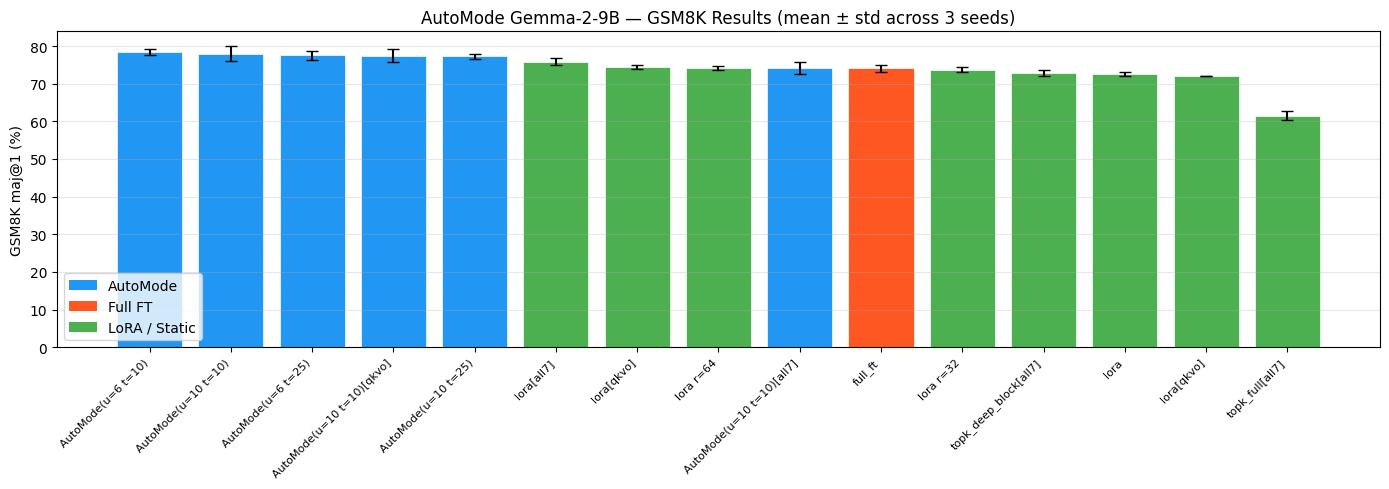

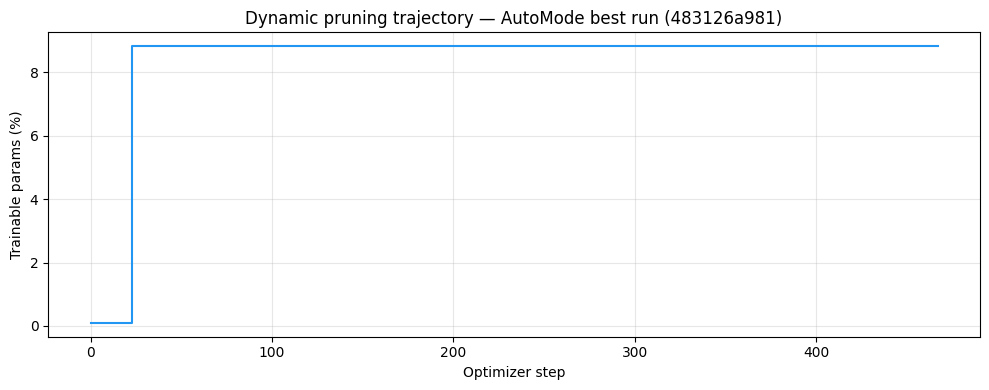

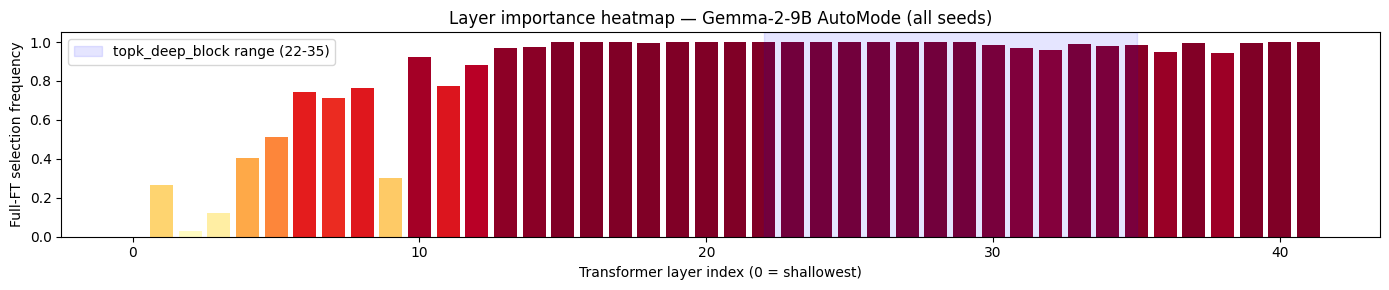


All figures saved to: /workspace/GSM8K_9B_Results


In [20]:
# ── Cell 14: Results visualisation ───────────────────────────────────────────
#
# Reproduces the key figures from the paper on the 9B results.
# Requires matplotlib; if not installed: !pip install matplotlib

try:
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
except ImportError:
    print("Install matplotlib:  !pip install matplotlib")
    raise

df, grouped = summarize_results()
if df is None or df.empty:
    print("No results to plot yet.")
    raise SystemExit

ok = df[df.get("status", "ok") == "ok"].copy() if "status" in df else df.copy()

# ── Figure A: maj@1 bar chart (mean ± std, sorted by mean) ──────────────────
fig, ax = plt.subplots(figsize=(14, 5))

if grouped is not None and not grouped.empty:
    # Build a readable label for each config
    def config_label(row):
        s = str(row.get("strategy", ""))
        if s == "dynamic_grad_norm":
            s = f"AutoMode(u={row.get('dynamic_updates','')} t={row.get('dynamic_threshold','')})"
        mods = str(row.get("target_modules", ""))
        if "gate_proj" in mods:
            s += "[all7]"
        elif "k_proj" in mods:
            s += "[qkvo]"
        r = row.get("lora_r")
        if pd.notna(r) and r != 16:
            s += f" r={int(r)}"
        return s

    grouped["label"] = grouped.apply(config_label, axis=1)
    grouped_s = grouped.sort_values("maj_mean", ascending=False)

    colors = ["#2196F3" if "AutoMode" in l else
              "#FF5722" if "full_ft"  in l else
              "#4CAF50" for l in grouped_s["label"]]

    ax.bar(range(len(grouped_s)), grouped_s["maj_mean"] * 100,
           yerr=grouped_s["maj_std"].fillna(0) * 100,
           color=colors, edgecolor="white", linewidth=0.5,
           capsize=4, error_kw={"elinewidth": 1.5})
    ax.set_xticks(range(len(grouped_s)))
    ax.set_xticklabels(grouped_s["label"], rotation=45, ha="right", fontsize=8)

ax.set_ylabel("GSM8K maj@1 (%)")
ax.set_title("AutoMode Gemma-2-9B — GSM8K Results (mean ± std across 3 seeds)")
ax.grid(axis="y", alpha=0.3)
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#2196F3", label="AutoMode"),
    Patch(facecolor="#FF5722", label="Full FT"),
    Patch(facecolor="#4CAF50", label="LoRA / Static"),
])
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/figure_maj1_bar.png", dpi=150)
plt.show()

# ── Figure B: Trainable parameter trajectory for the best AutoMode run ────────
# Find the best-performing dynamic_grad_norm experiment
if not ok.empty and "strategy" in ok.columns:
    dynamic_runs = ok[ok["strategy"] == "dynamic_grad_norm"]
    if not dynamic_runs.empty:
        best_id = dynamic_runs.loc[dynamic_runs["maj@1"].idxmax(), "exp_id"]
        traj_path = f"{SAVE_PATH}/trainable_trajectory_{best_id}.json"

        if os.path.exists(traj_path):
            with open(traj_path) as f:
                traj = json.load(f)

            steps   = [t["step"]           for t in traj]
            pct     = [t["trainable_pct"] * 100 for t in traj]

            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(steps, pct, color="#2196F3", linewidth=1.5)
            ax.set_xlabel("Optimizer step")
            ax.set_ylabel("Trainable params (%)")
            ax.set_title(f"Dynamic pruning trajectory — AutoMode best run ({best_id})")
            ax.grid(alpha=0.3)
            plt.tight_layout()
            plt.savefig(f"{SAVE_PATH}/figure_trajectory_{best_id}.png", dpi=150)
            plt.show()

# ── Figure C: Layer heatmap (importance frequency) ───────────────────────────
# Counts how often each of the 42 Gemma-2-9B layers is selected for Full-FT
# across all AutoMode steps and seeds.
if not ok.empty and "strategy" in ok.columns:
    dynamic_ids = ok[ok["strategy"] == "dynamic_grad_norm"]["exp_id"].tolist()
    layer_counts = defaultdict(int)
    total_steps  = 0

    for eid in dynamic_ids:
        flog_path = f"{SAVE_PATH}/dynamic_log_{eid}.json"
        if not os.path.exists(flog_path):
            continue
        with open(flog_path) as f:
            flog = json.load(f)
        for entry in flog:
            total_steps += 1
            for lname, info in entry.get("layers", {}).items():
                if info.get("action") == "full_ft":
                    # Extract layer index from 'model.layers.N'
                    parts = lname.split(".")
                    if "layers" in parts:
                        idx = parts[parts.index("layers") + 1]
                        layer_counts[int(idx)] += 1

    if layer_counts and total_steps > 0:
        n_layers = 42   # Gemma-2-9B
        freq = [layer_counts.get(i, 0) / total_steps for i in range(n_layers)]

        fig, ax = plt.subplots(figsize=(14, 3))
        ax.bar(range(n_layers), freq, color=cm.YlOrRd(np.array(freq)))
        ax.set_xlabel("Transformer layer index (0 = shallowest)")
        ax.set_ylabel("Full-FT selection frequency")
        ax.set_title("Layer importance heatmap — Gemma-2-9B AutoMode (all seeds)")
        ax.axvspan(22, 35, alpha=0.1, color="blue", label="topk_deep_block range (22-35)")
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"{SAVE_PATH}/figure_layer_heatmap.png", dpi=150)
        plt.show()

print("\nAll figures saved to:", SAVE_PATH)